Notebook 08 — Real-Data Empirical Backtest (BTC / ETH)
=======================================================
Strategies compared
-------------------
  optimal      — Guéant ODE quotes (Model A, xi = gamma)
  closed_form  — GLFT closed-form approximation (far-from-T asymptotic)
  naive        — fixed symmetric half-spread (no skew, no drift awareness)
  optimal_b    — Guéant ODE quotes under Model B (xi = 0): running inventory
                 penalty instead of CARA utility. Averse to price risk only,
                 not to fill-timing risk. Directly replicates Guéant (2017)
                 Figures 8/9 comparison on real BTC/ETH data.

Fixes vs previous version
--------------------------
  • Mid-price files: tries .parquet first, falls back to .csv (consistent
    with NB09 / NB10 which already used .parquet).
  • optimal_b (Model B, xi=0) added as fourth strategy — meaningful scientific
    comparison vs Model A, directly from Guéant (2017) Section 3.4.
  • display() replaced with print() so the file runs as a plain .py script.
  • Poisson comparison cell wrapped in a try/except so it degrades gracefully
    if market_making.simulation.backtest is unavailable.
  • Win-rate summary now compares every pair of strategies, not just
    optimal vs naive.

In [1]:
import json
import pickle
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm, kurtosis, skew

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.core.solver_1d import solve_general
from market_making.core.closed_form import approx_quotes
from market_making.core.intensity import C_coeff, fill_prob, Lambda

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8")

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = Path.cwd().parents[0]
DATA_DIR    = ROOT / "data/data/calibrated"
CKPT_DIR    = DATA_DIR / "checkpoints_tardis"
PARAMS_FILE = DATA_DIR / "calibrated_params.json"

SYMBOLS       = ["BTCUSDT", "ETHUSDT"]
DEFAULT_GAMMA = 0.01

assert PARAMS_FILE.exists(), f"Run the calibration notebook first — {PARAMS_FILE} not found"

with open(PARAMS_FILE) as fh:
    raw_params = json.load(fh)

all_params    = {}
all_mid       = {}
all_intervals = {}

for symbol in SYMBOLS:
    cal = raw_params[symbol]
    all_params[symbol] = {
        "sigma":    cal["sigma"],
        "A":        cal["A"],
        "k":        cal["k"],
        "Delta":    cal["Delta"],
        "Q":        cal.get("Q", 4),
        "lot_size": cal["lot_size"],
    }

    # Mid-prices — prefer parquet, fall back to csv
    pq_path  = DATA_DIR / f"mid_prices_{symbol}.parquet"
    csv_path = DATA_DIR / f"mid_prices_{symbol}.csv"
    if pq_path.exists():
        all_mid[symbol] = pd.read_parquet(pq_path)["mid_price"]
    elif csv_path.exists():
        all_mid[symbol] = pd.read_csv(csv_path, index_col=0, parse_dates=True)["mid_price"]
    else:
        raise FileNotFoundError(f"No mid-price file for {symbol} in {DATA_DIR}")

    # Interval table from Tardis MLE checkpoint
    ckpt_file = CKPT_DIR / f"{symbol}_mle.pkl"
    if ckpt_file.exists():
        with open(ckpt_file, "rb") as fh:
            ckpt = pickle.load(fh)
        all_intervals[symbol] = pd.concat(ckpt["interval_tables"], ignore_index=True)
    else:
        print(f"  WARNING: no checkpoint for {symbol} — empirical backtests will be skipped")

print(f"{'='*65}")
print(f"  Calibrated Parameters (Tardis L1 MLE)")
print(f"{'='*65}")
for symbol in SYMBOLS:
    p   = all_params[symbol]
    cal = raw_params[symbol]
    mid = all_mid[symbol]
    n_int = len(all_intervals.get(symbol, []))
    print(f"\n  {symbol}")
    print(f"    sigma    = {p['sigma']:.6f}  $/sqrt(s)")
    print(f"    A        = {p['A']:.6f}  1/s")
    print(f"    k        = {p['k']:.6f}  1/$")
    print(f"    Delta    = {p['Delta']:.2f}  $ (notional per lot)")
    print(f"    lot_size = {p['lot_size']}  (asset qty per lot)")
    print(f"    Q        = {p['Q']}  lots")
    print(f"    R²       = {cal.get('r_squared', '?')}")
    print(f"    Mid:       {len(mid):,} pts,  ${mid.min():,.2f} — ${mid.max():,.2f}")
    print(f"    Intervals: {n_int:,}")

  Calibrated Parameters (Tardis L1 MLE)

  BTCUSDT
    sigma    = 5.015861  $/sqrt(s)
    A        = 0.502752  1/s
    k        = 1.009890  1/$
    Delta    = 85.07  $ (notional per lot)
    lot_size = 0.001  (asset qty per lot)
    Q        = 4  lots
    R²       = 0.0608
    Mid:       518,350 pts,  $60,133.35 — $102,734.85
    Intervals: 7,829,659

  ETHUSDT
    sigma    = 0.269903  $/sqrt(s)
    A        = 0.762207  1/s
    k        = 8.600289  1/$
    Delta    = 29.33  $ (notional per lot)
    lot_size = 0.01  (asset qty per lot)
    Q        = 4  lots
    R²       = 0.3738
    Mid:       518,344 pts,  $2,142.51 — $3,749.99
    Intervals: 8,405,829


In [3]:
# ── Session-aware helper functions ────────────────────────────────────────────

def returns_by_session(mid: pd.Series) -> pd.Series:
    """1-second returns computed within each calendar-day session."""
    df = mid.to_frame("mid")
    df["session"] = df.index.date
    return df.groupby("session")["mid"].diff().dropna()


def hourly_sigma_by_session(mid: pd.Series) -> pd.Series:
    """Per-hour volatility averaged across sessions."""
    df = mid.to_frame("mid")
    df["session"] = df.index.date
    df["ret"] = df.groupby("session")["mid"].diff()
    df_clean = df.dropna(subset=["ret"])
    return df_clean.groupby(df_clean.index.hour)["ret"].std()


def rolling_sigma_by_session(mid: pd.Series, window: int = 300) -> pd.Series:
    """Rolling sigma within each session (never crosses session boundaries)."""
    df = mid.to_frame("mid")
    df["session"] = df.index.date
    out = []
    for _, g in df.groupby("session"):
        out.append(g["mid"].diff().rolling(window).std())
    return pd.concat(out).dropna().sort_index()


print("Session-aware helpers defined.")

Session-aware helpers defined.


### Mid-price overview ───────────────────────────────────

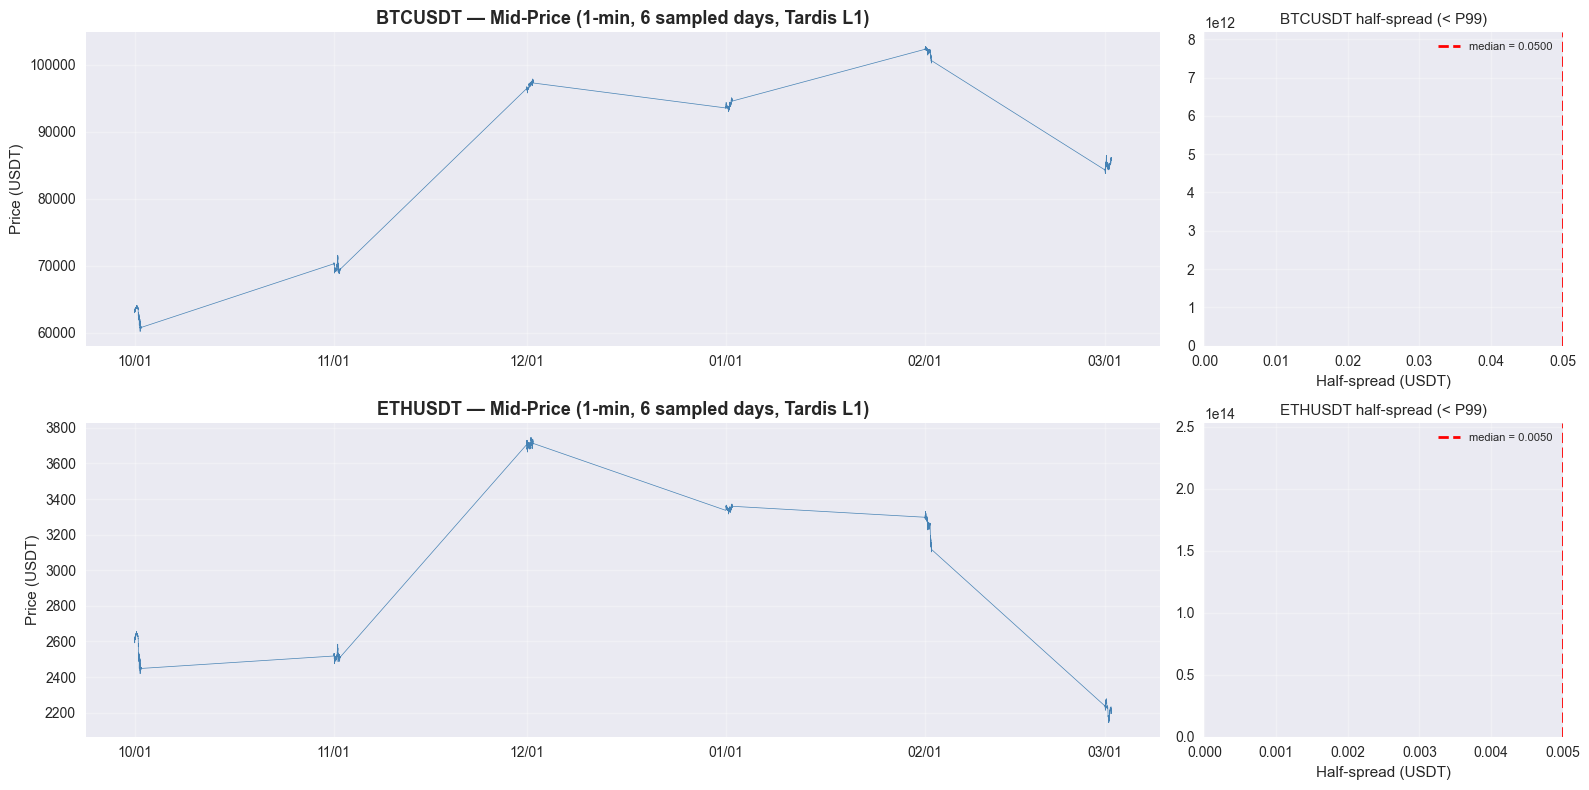

In [4]:
fig, axes = plt.subplots(len(SYMBOLS), 2, figsize=(16, 4 * len(SYMBOLS)),
                         gridspec_kw={"width_ratios": [3, 1]})
if len(SYMBOLS) == 1:
    axes = axes.reshape(1, 2)

for row, symbol in enumerate(SYMBOLS):
    mid      = all_mid[symbol]
    mid_1min = mid.resample("1min").mean().dropna()

    ax = axes[row, 0]
    ax.plot(mid_1min.index, mid_1min.values, lw=0.5, color="steelblue")
    n_days = raw_params[symbol].get("n_days", "?")
    ax.set_title(f"{symbol} — Mid-Price (1-min, {n_days} sampled days, Tardis L1)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (USDT)")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

    ax = axes[row, 1]
    if symbol in all_intervals:
        hs  = all_intervals[symbol]["half_spread"].dropna()
        cap = hs.quantile(0.99)
        ax.hist(hs[hs <= cap], bins=100, density=True, alpha=0.7, color="darkorange")
        ax.axvline(hs.median(), color="red", ls="--", lw=2,
                   label=f"median = {hs.median():.4f}")
        ax.set_title(f"{symbol} half-spread (< P99)", fontsize=11)
        ax.set_xlabel("Half-spread (USDT)")
        ax.set_xlim(0, cap)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Return distribution ──────────────────────────────────

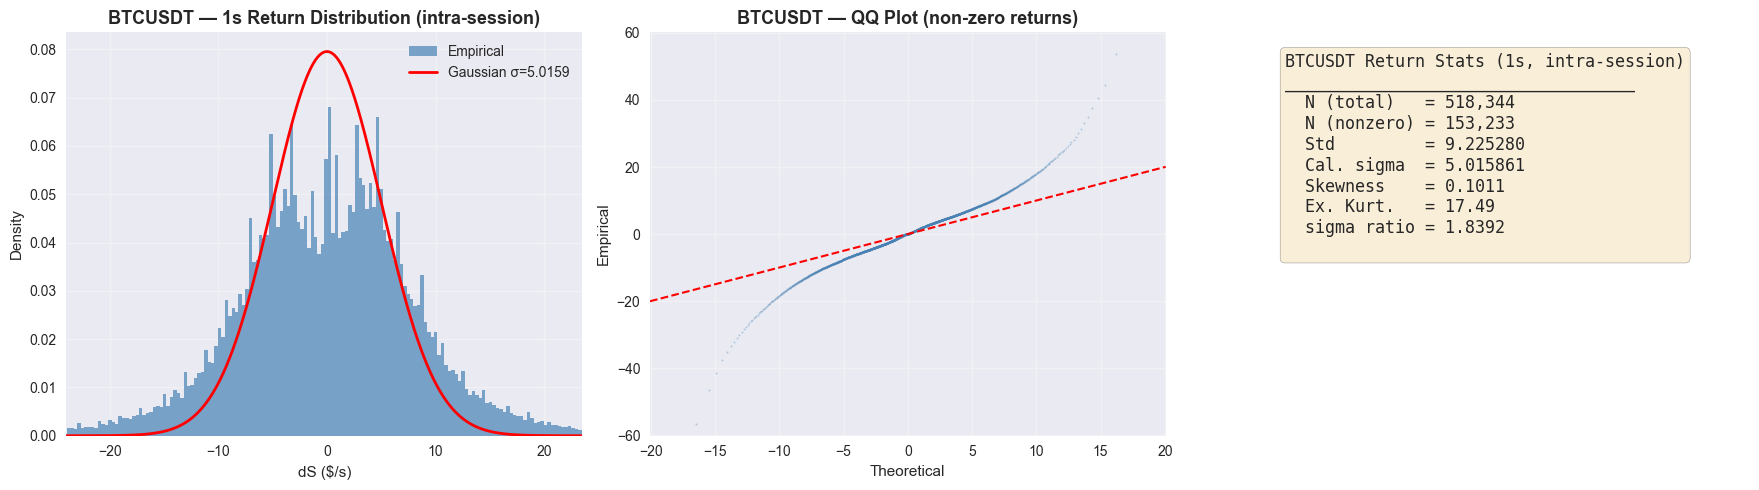

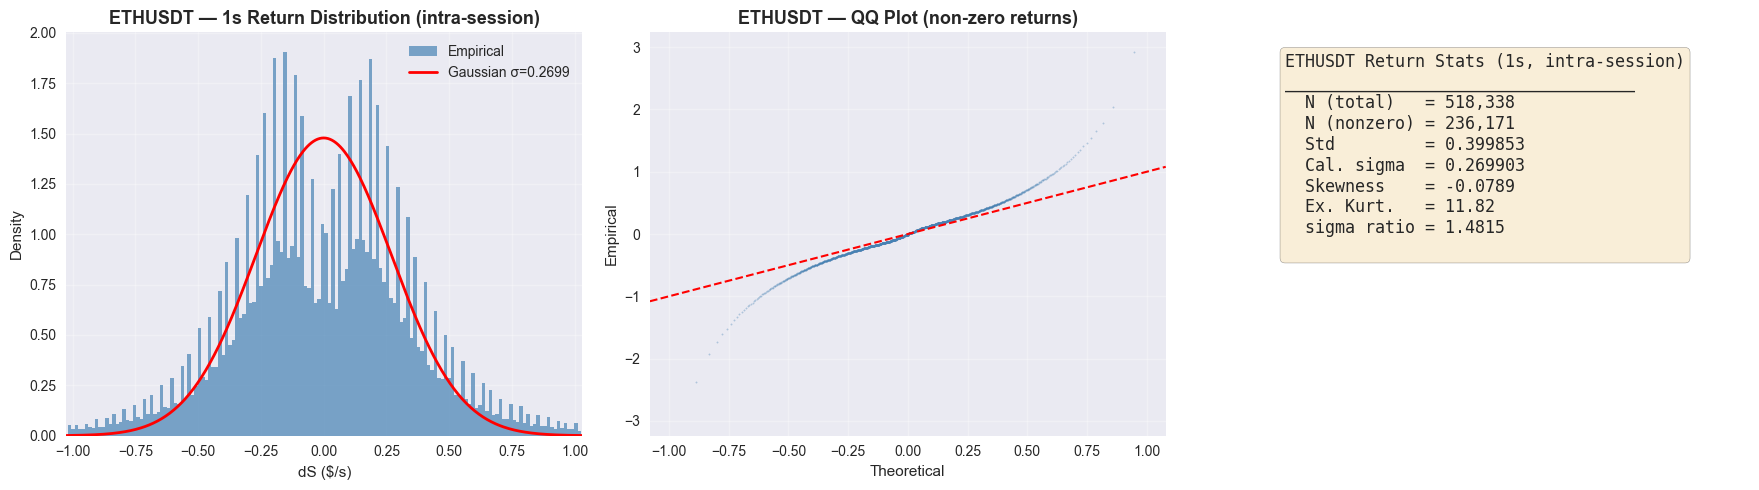

In [5]:
for symbol in SYMBOLS:
    mid    = all_mid[symbol]
    sigma  = all_params[symbol]["sigma"]
    returns_1s = returns_by_session(mid)

    returns_nonzero = returns_1s[returns_1s != 0]
    q_lo, q_hi = returns_nonzero.quantile([0.01, 0.99])
    returns_trimmed = returns_nonzero[
        (returns_nonzero > q_lo) & (returns_nonzero < q_hi)
    ]

    fig, axes_r = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes_r[0]
    ax.hist(returns_trimmed, bins=150, density=True, alpha=0.7,
            color="steelblue", label="Empirical")
    x_g = np.linspace(q_lo, q_hi, 500)
    ax.plot(x_g, norm.pdf(x_g, 0, sigma), "r-", lw=2,
            label=f"Gaussian σ={sigma:.4f}")
    ax.set_title(f"{symbol} — 1s Return Distribution (intra-session)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("dS ($/s)")
    ax.set_ylabel("Density")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(q_lo, q_hi)

    ax = axes_r[1]
    sorted_r    = np.sort(returns_nonzero.values)
    n_r         = len(sorted_r)
    theoretical = norm.ppf(np.linspace(1/(n_r+1), n_r/(n_r+1), n_r), 0, sigma)
    step = max(1, n_r // 2000)
    lim  = 4 * sigma
    ax.scatter(theoretical[::step], sorted_r[::step], s=1, alpha=0.3, color="steelblue")
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.5)
    ax.set_title(f"{symbol} — QQ Plot (non-zero returns)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Theoretical"); ax.set_ylabel("Empirical")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-3*lim, 3*lim)

    ax = axes_r[2]
    ax.axis("off")
    kurt_val = kurtosis(returns_nonzero.dropna())
    skew_val = skew(returns_nonzero.dropna())
    stats_text = (
        f"{symbol} Return Stats (1s, intra-session)\n"
        f"{'_'*35}\n"
        f"  N (total)   = {len(returns_1s):,}\n"
        f"  N (nonzero) = {len(returns_nonzero):,}\n"
        f"  Std         = {returns_nonzero.std():.6f}\n"
        f"  Cal. sigma  = {sigma:.6f}\n"
        f"  Skewness    = {skew_val:.4f}\n"
        f"  Ex. Kurt.   = {kurt_val:.2f}\n"
        f"  sigma ratio = {returns_nonzero.std()/sigma:.4f}\n"
    )
    ax.text(0.1, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    plt.tight_layout(); plt.show()

### Hourly volatility ────────────────────────────────────

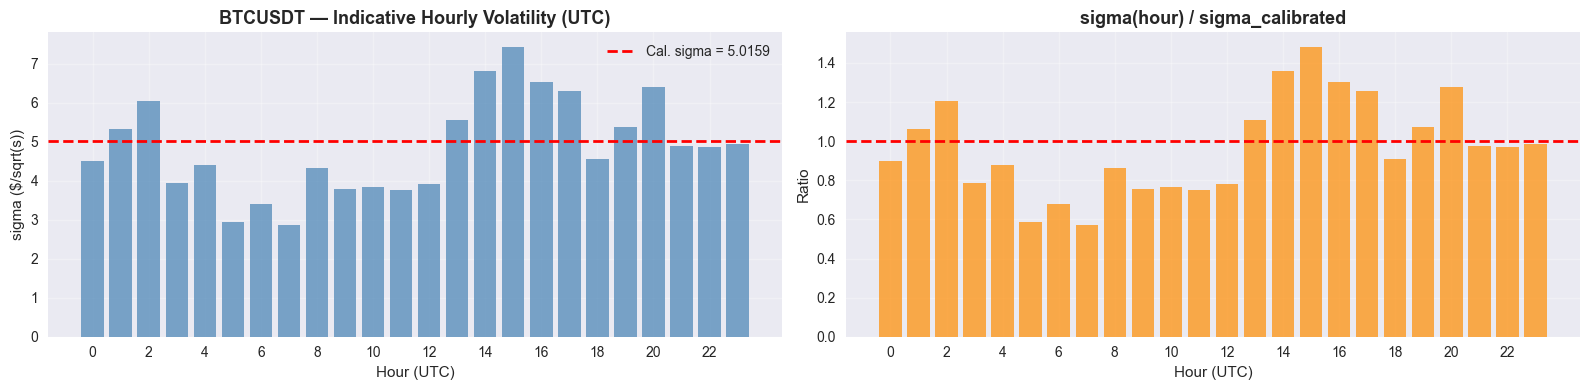

  BTCUSDT: peak 15:00 (1.5×), trough 7:00 (0.6×)


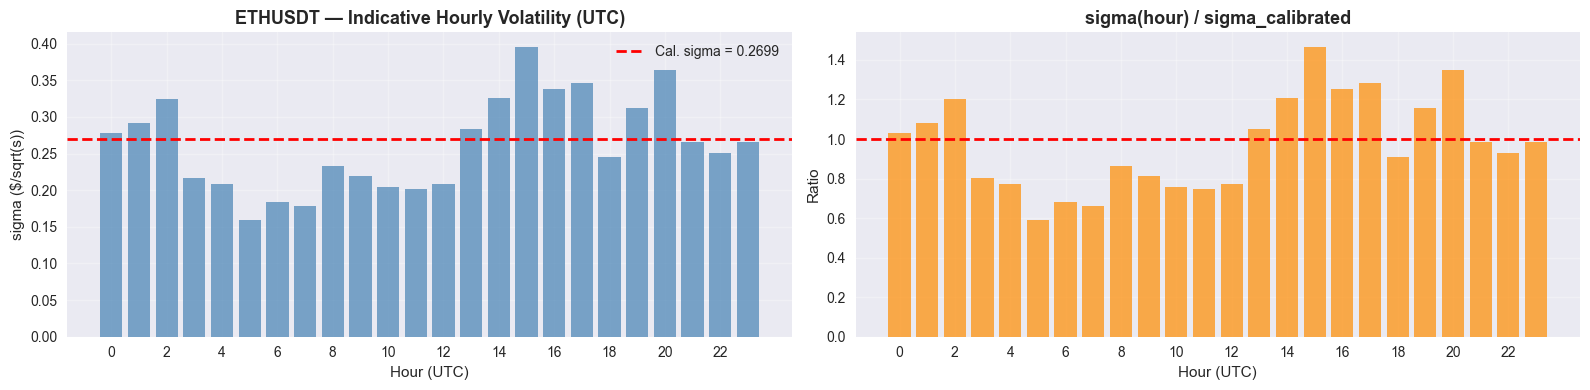

  ETHUSDT: peak 15:00 (1.5×), trough 5:00 (0.6×)


In [6]:
for symbol in SYMBOLS:
    mid          = all_mid[symbol]
    sigma        = all_params[symbol]["sigma"]
    hourly_sigma = hourly_sigma_by_session(mid)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

    ax1.bar(hourly_sigma.index, hourly_sigma.values, alpha=0.7, color="steelblue")
    ax1.axhline(sigma, color="red", ls="--", lw=2, label=f"Cal. sigma = {sigma:.4f}")
    ax1.set_title(f"{symbol} — Indicative Hourly Volatility (UTC)",
                  fontsize=13, fontweight="bold")
    ax1.set_xlabel("Hour (UTC)"); ax1.set_ylabel("sigma ($/sqrt(s))")
    ax1.set_xticks(range(0, 24, 2)); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.bar(hourly_sigma.index, hourly_sigma.values / sigma, alpha=0.7, color="darkorange")
    ax2.axhline(1, color="red", ls="--", lw=2)
    ax2.set_title("sigma(hour) / sigma_calibrated", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Hour (UTC)"); ax2.set_ylabel("Ratio")
    ax2.set_xticks(range(0, 24, 2)); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    peak   = hourly_sigma.idxmax()
    trough = hourly_sigma.idxmin()
    print(f"  {symbol}: peak {peak}:00 ({hourly_sigma.max()/sigma:.1f}×), "
          f"trough {trough}:00 ({hourly_sigma.min()/sigma:.1f}×)")

### Return autocorrelation ────────────────────────────────

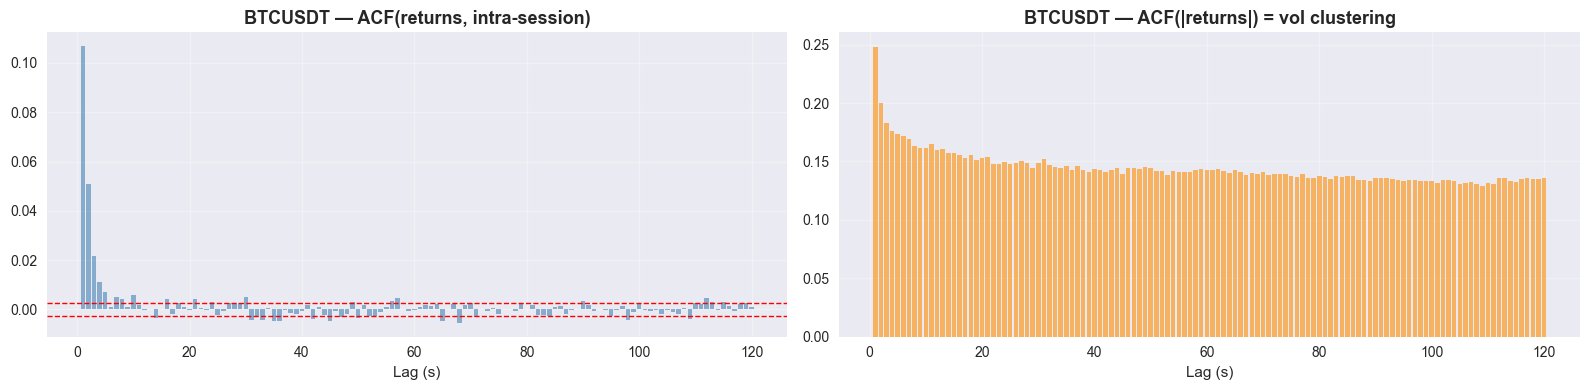

  BTCUSDT: ACF(r,1)=0.1068,  ACF(|r|,1)=0.2481


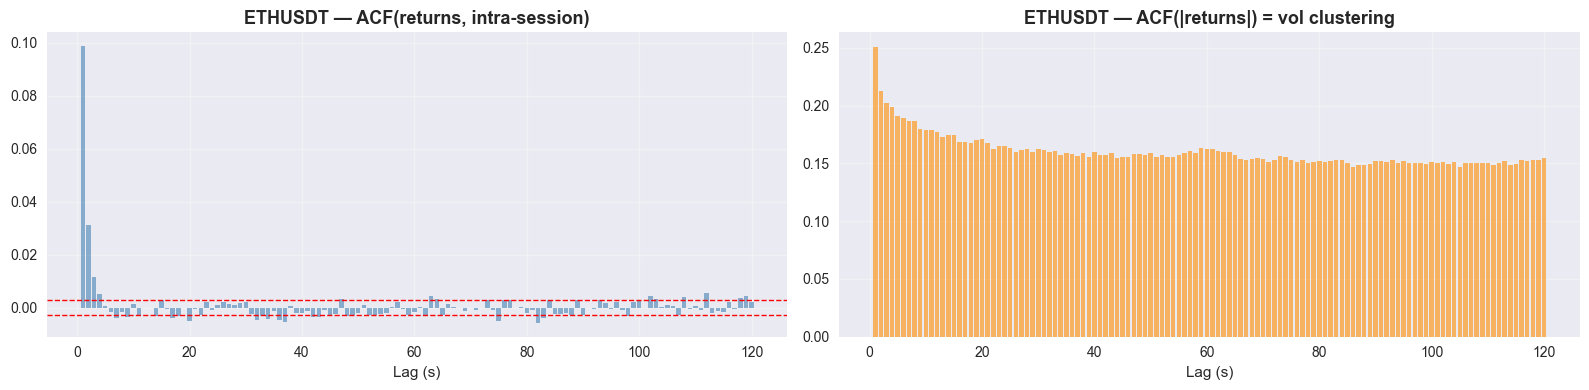

  ETHUSDT: ACF(r,1)=0.0988,  ACF(|r|,1)=0.2508


In [7]:
max_lag = 120

for symbol in SYMBOLS:
    mid    = all_mid[symbol]
    r_vals = returns_by_session(mid).values

    acf_r   = [np.corrcoef(r_vals[:-lag], r_vals[lag:])[0, 1] for lag in range(1, max_lag + 1)]
    abs_r   = np.abs(r_vals)
    acf_abs = [np.corrcoef(abs_r[:-lag], abs_r[lag:])[0, 1] for lag in range(1, max_lag + 1)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
    ax1.bar(range(1, max_lag + 1), acf_r, alpha=0.6, color="steelblue")
    ax1.axhline( 1.96/np.sqrt(len(r_vals)), color="red", ls="--", lw=1)
    ax1.axhline(-1.96/np.sqrt(len(r_vals)), color="red", ls="--", lw=1)
    ax1.set_title(f"{symbol} — ACF(returns, intra-session)", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Lag (s)"); ax1.grid(True, alpha=0.3)

    ax2.bar(range(1, max_lag + 1), acf_abs, alpha=0.6, color="darkorange")
    ax2.set_title(f"{symbol} — ACF(|returns|) = vol clustering", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Lag (s)"); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f"  {symbol}: ACF(r,1)={acf_r[0]:.4f},  ACF(|r|,1)={acf_abs[0]:.4f}")

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  Dataclass + backtest engine
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class EmpiricalBtResult:
    """Result from a single empirical backtest window."""
    timestamps:          np.ndarray
    mid_prices:          np.ndarray
    inventory:           np.ndarray   # length N+1 (includes t=0 state)
    cash:                np.ndarray   # length N+1
    mtm:                 np.ndarray   # mark-to-market P&L, length N+1
    n_bid_fills:         int
    n_ask_fills:         int
    n_bid_passive:       int          # intervals where bid was posted passively
    n_ask_passive:       int
    delta_bid_posted:    np.ndarray   # length N
    delta_ask_posted:    np.ndarray   # length N
    market_half_spread:  np.ndarray
    fees_paid:           float
    strategy:            str
    gamma:               float
    symbol:              str
    drift_per_sec:       float = 0.0  # unused, kept for backward compat

    @property
    def pnl(self)             -> float: return float(self.mtm[-1])
    @property
    def total_fills(self)     -> int:   return self.n_bid_fills + self.n_ask_fills
    @property
    def final_inventory(self) -> int:   return int(self.inventory[-1])
    @property
    def bid_passive_rate(self) -> float:
        N = len(self.delta_bid_posted)
        return self.n_bid_passive / N if N > 0 else 0.0
    @property
    def ask_passive_rate(self) -> float:
        N = len(self.delta_ask_posted)
        return self.n_ask_passive / N if N > 0 else 0.0
    @property
    def mean_spread(self) -> float:
        return float(np.nanmean(self.delta_bid_posted + self.delta_ask_posted))





def run_backtest_real_lob(
    intervals: pd.DataFrame,
    params:    dict,
    gamma:     float,
    strategy:  str   = "optimal",
    maker_fee: float = 0.0001,
    symbol:    str   = "",
) -> EmpiricalBtResult:
    """Deterministic backtest on real L1 interval data.

    Parameters
    ----------
    intervals : DataFrame with columns
                  timestamp, mid, half_spread,
                  max_buy_price, min_sell_price, dt
    params    : sigma, A, k, Delta, Q, lot_size
    gamma     : risk-aversion coefficient
    strategy  : "optimal" | "optimal_b" | "closed_form" | "naive"
    maker_fee : proportional fee per fill (1 bps = 0.0001)
    """
    sigma    = params["sigma"]
    A        = params["A"]
    k        = params["k"]
    Delta    = params["Delta"]
    Q        = int(params["Q"])
    lot_size = params["lot_size"]
    xi       = gamma                 # Model A

    intervals = intervals.sort_values("timestamp").reset_index(drop=True)
    N         = len(intervals)
    n_states  = 2 * Q + 1
    T_total   = float(intervals["dt"].sum())

    # ── Pre-compute ODE solution ────────────────────────────────────────────
    # Model A (xi = gamma): CARA utility, averse to both price and fill risk
    # Model B (xi = 0):     running inventory penalty, averse to price risk only
    N_t_ode  = max(300, int(T_total))
    sol_a    = solve_general(params, gamma, T_total, xi=gamma,  N_t=N_t_ode)
    sol_b    = solve_general(params, gamma, T_total, xi=0.0,    N_t=N_t_ode)
    if strategy == "optimal_b":
        db_table = sol_b["delta_bid"]
        da_table = sol_b["delta_ask"]
    else:
        db_table = sol_a["delta_bid"]   # shape (N_t_ode+1, 2Q+1)
        da_table = sol_a["delta_ask"]

    # Asymptotic half-spread (t=0, n=0): used by naive.
    # Index 0 corresponds to the START of the horizon (far from T), which is
    # the stationary regime — the correct reference for a flat, symmetric quote.
    half_spread_naive = float(db_table[0, Q])

    # ── Closed-form table ────────────────────────────────────────────────────
    db_cf = da_cf = None
    if strategy == "closed_form":
        n_arr        = np.arange(-Q, Q + 1)
        db_cf, da_cf = approx_quotes(n_arr, params, gamma, xi=xi)

    mids_arr = intervals["mid"].values
    dts_arr  = intervals["dt"].values

    # ── Raw data arrays ───────────────────────────────────────────────────────
    half_spreads = intervals["half_spread"].values
    max_buy      = intervals["max_buy_price"].values
    min_sell     = intervals["min_sell_price"].values
    timestamps   = intervals["timestamp"].values

    # ── State arrays ─────────────────────────────────────────────────────────
    inventory  = np.zeros(N + 1, dtype=int)
    cash_arr   = np.zeros(N + 1)
    mtm_arr    = np.zeros(N + 1)
    db_posted  = np.full(N, np.nan)
    da_posted  = np.full(N, np.nan)

    n_inv = 0; X = 0.0
    n_bid = 0; n_ask = 0
    n_bid_passive = 0; n_ask_passive = 0
    fees = 0.0

    # Cumulative time → ODE time index
    cum_t = np.insert(np.cumsum(dts_arr), 0, 0.0)

    for i in range(N):
        mid_i = mids_arr[i]
        hs_i  = half_spreads[i]
        i_lot = n_inv + Q          # lot index in [0, 2Q]

        # ── Quote computation ─────────────────────────────────────────────
        if strategy == "optimal":
            t_frac = cum_t[i] / T_total if T_total > 0 else 0.0
            t_idx  = min(int(t_frac * N_t_ode), N_t_ode - 1)
            db = (db_table[t_idx, i_lot]
                  if n_inv < Q and np.isfinite(db_table[t_idx, i_lot]) else np.inf)
            da = (da_table[t_idx, i_lot]
                  if n_inv > -Q and np.isfinite(da_table[t_idx, i_lot]) else np.inf)

        elif strategy == "naive":
            db = half_spread_naive if n_inv < Q  else np.inf
            da = half_spread_naive if n_inv > -Q else np.inf

        elif strategy == "optimal_b":
            # Model B already loaded into db_table/da_table above
            t_frac = cum_t[i] / T_total if T_total > 0 else 0.0
            t_idx  = min(int(t_frac * N_t_ode), N_t_ode - 1)
            db = (db_table[t_idx, i_lot]
                  if n_inv < Q and np.isfinite(db_table[t_idx, i_lot])
                  else np.inf)
            da = (da_table[t_idx, i_lot]
                  if n_inv > -Q and np.isfinite(da_table[t_idx, i_lot])
                  else np.inf)

        elif strategy == "closed_form":
            db = (db_cf[i_lot]
                  if n_inv < Q  and 0 <= i_lot < len(db_cf) else np.inf)
            da = (da_cf[i_lot]
                  if n_inv > -Q and 0 <= i_lot < len(da_cf) else np.inf)

        else:
            raise ValueError(f"Unknown strategy: {strategy!r}")

        db_posted[i] = db
        da_posted[i] = da

        # ── Passivity: quote must sit at or outside current best spread ───
        # A quote is passive as long as it doesn't cross the spread (db >= 0).
        # hs_i was previously used here but incorrectly blocked ODE quotes
        # that are correctly sized yet smaller than the market half-spread.
        # The fill condition below already enforces that aggressive flow
        # actually reaches the quoted price.
        bid_passive = np.isfinite(db) and db >= 0
        ask_passive = np.isfinite(da) and da >= 0
        if bid_passive: n_bid_passive += 1
        if ask_passive: n_ask_passive += 1

        bid_price = mid_i - db if bid_passive else np.nan
        ask_price = mid_i + da if ask_passive else np.nan

        # ── Fill detection from real aggressive flow ──────────────────────
        bid_fill = (bid_passive
                    and np.isfinite(min_sell[i])
                    and min_sell[i] <= bid_price)
        ask_fill = (ask_passive
                    and np.isfinite(max_buy[i])
                    and max_buy[i] >= ask_price)

        # ── Execute fills ─────────────────────────────────────────────────
        if bid_fill:
            fee   = maker_fee * abs(bid_price) * lot_size
            X    -= bid_price * lot_size + fee
            n_inv = min(n_inv + 1, Q)
            n_bid += 1; fees += fee

        if ask_fill:
            fee   = maker_fee * abs(ask_price) * lot_size
            X    += ask_price * lot_size - fee
            n_inv = max(n_inv - 1, -Q)
            n_ask += 1; fees += fee

        inventory[i + 1] = n_inv
        cash_arr[i + 1]  = X
        mtm_arr[i + 1]   = X + n_inv * lot_size * mid_i

    mtm_arr[-1] = cash_arr[-1] + inventory[-1] * lot_size * mids_arr[-1]

    return EmpiricalBtResult(
        timestamps=timestamps, mid_prices=mids_arr,
        inventory=inventory, cash=cash_arr, mtm=mtm_arr,
        n_bid_fills=n_bid, n_ask_fills=n_ask,
        n_bid_passive=n_bid_passive, n_ask_passive=n_ask_passive,
        delta_bid_posted=db_posted, delta_ask_posted=da_posted,
        market_half_spread=half_spreads.copy(),
        fees_paid=fees, strategy=strategy, gamma=gamma,
        symbol=symbol, drift_per_sec=0.0,
    )


print("run_backtest_real_lob() defined.")
print("  Strategies: optimal (Model A) | optimal_b (Model B) | closed_form | naive")
print(f"  Units: cash in USD, inventory in lots, fills use lot_size")

run_backtest_real_lob() defined.
  Strategies: optimal (Model A) | optimal_b (Model B) | closed_form | naive
  Units: cash in USD, inventory in lots, fills use lot_size


### Single-window comparison ─────────────────────────────

In [9]:
STRATEGIES = ["optimal", "optimal_b", "naive", "closed_form"]
LABELS = {
    "optimal":     "Optimal (ODE)",
    "naive":       "Naive (symmetric)",
    "optimal_b":   "Optimal (Model B)",
    "closed_form": "Closed-form",
}
COLORS = {
    "optimal":     "#00a882",
    "naive":       "#e05050",
    "optimal_b":   "#f59e0b",
    "closed_form": "#8b5cf6",
}

WINDOW_SECONDS    = 3600
single_window_results = {}

for symbol in SYMBOLS:
    if symbol not in all_intervals:
        continue
    iv     = all_intervals[symbol]
    params = all_params[symbol]

    # Pick the middle of the dataset as a representative window
    mid_ts = iv["timestamp"].iloc[len(iv) // 2]
    end_ts = mid_ts + pd.Timedelta(seconds=WINDOW_SECONDS)
    window = iv[(iv["timestamp"] >= mid_ts) & (iv["timestamp"] < end_ts)].copy()

    if len(window) < 100:
        print(f"  {symbol}: window too small ({len(window)} intervals), skipping")
        continue

    actual_span = (window["timestamp"].max() - window["timestamp"].min()).total_seconds()
    print(f"\n{symbol} — single window: {mid_ts}  (+{actual_span:.0f}s, {len(window):,} intervals)")

    single_window_results[symbol] = {}
    for strat in STRATEGIES:
        res = run_backtest_real_lob(
            window, params, DEFAULT_GAMMA,
            strategy=strat, maker_fee=0.0001, symbol=symbol,
        )
        single_window_results[symbol][strat] = res

        print(f"  {LABELS[strat]:22s}:  "
              f"PnL={res.pnl:+.6f} $,  "
              f"fills={res.total_fills:3d} (bid={res.n_bid_fills}, ask={res.n_ask_fills}),  "
              f"inv_T={res.final_inventory:+d},  "
              f"passive b={res.bid_passive_rate:.0%} a={res.ask_passive_rate:.0%}")


BTCUSDT — single window: 2024-12-01 02:21:01.520000  (+3600s, 59,254 intervals)
  Optimal (ODE)         :  PnL=-0.011921 $,  fills=  4 (bid=4, ask=0),  inv_T=+4,  passive b=3% a=0%
  Optimal (Model B)     :  PnL=-0.012166 $,  fills=  4 (bid=4, ask=0),  inv_T=+4,  passive b=3% a=0%
  Naive (symmetric)     :  PnL=-5.493741 $,  fills=359 (bid=178, ask=181),  inv_T=-3,  passive b=84% a=94%
  Closed-form           :  PnL=+0.695008 $,  fills=  4 (bid=4, ask=0),  inv_T=+4,  passive b=27% a=0%

ETHUSDT — single window: 2024-12-01 00:33:49.482000  (+3600s, 64,421 intervals)
  Optimal (ODE)         :  PnL=-1.180972 $,  fills= 30 (bid=17, ask=13),  inv_T=+4,  passive b=4% a=2%
  Optimal (Model B)     :  PnL=-1.180430 $,  fills= 30 (bid=17, ask=13),  inv_T=+4,  passive b=4% a=2%
  Naive (symmetric)     :  PnL=-17.359793 $,  fills=2536 (bid=1266, ask=1270),  inv_T=-4,  passive b=84% a=83%
  Closed-form           :  PnL=-1.180986 $,  fills= 30 (bid=17, ask=13),  inv_T=+4,  passive b=4% a=2%


### Single-window plot ───────────────────────────────────

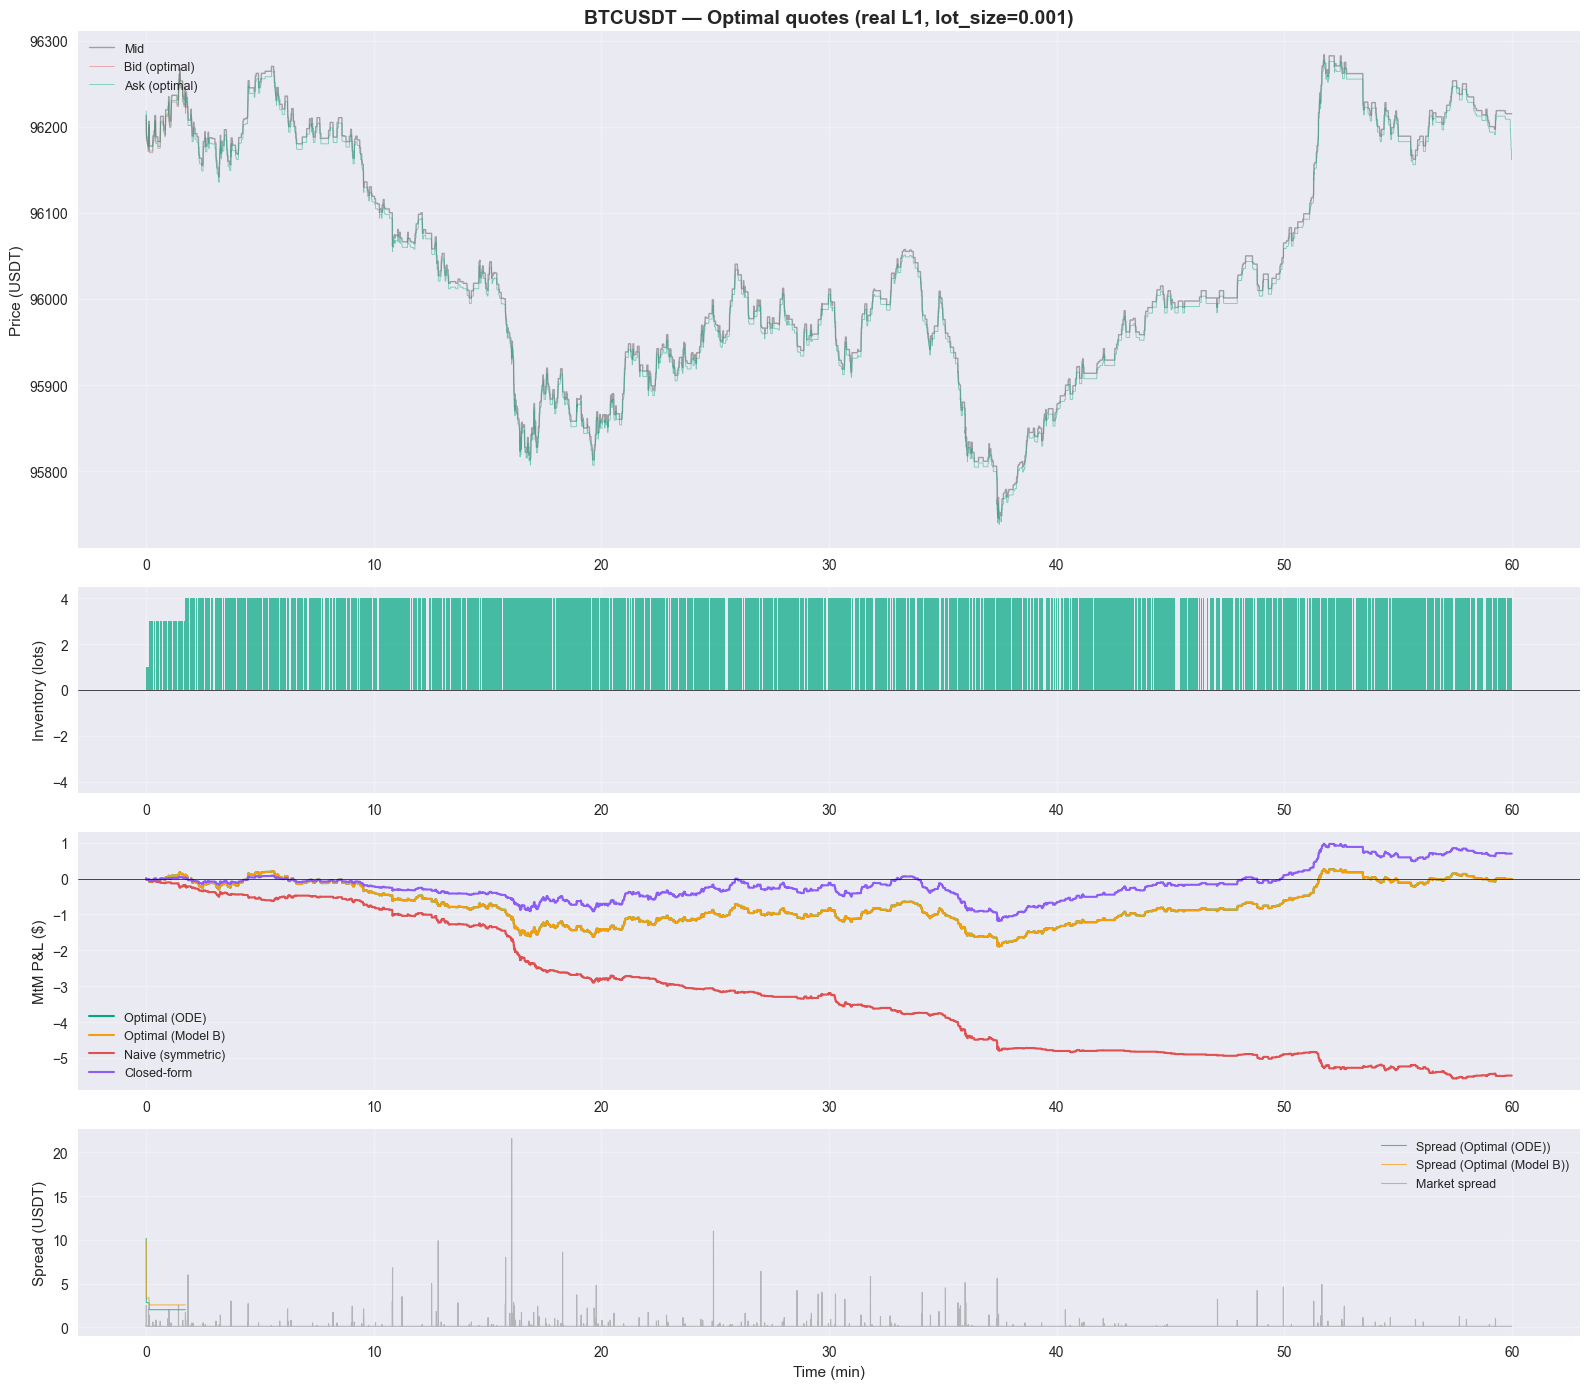

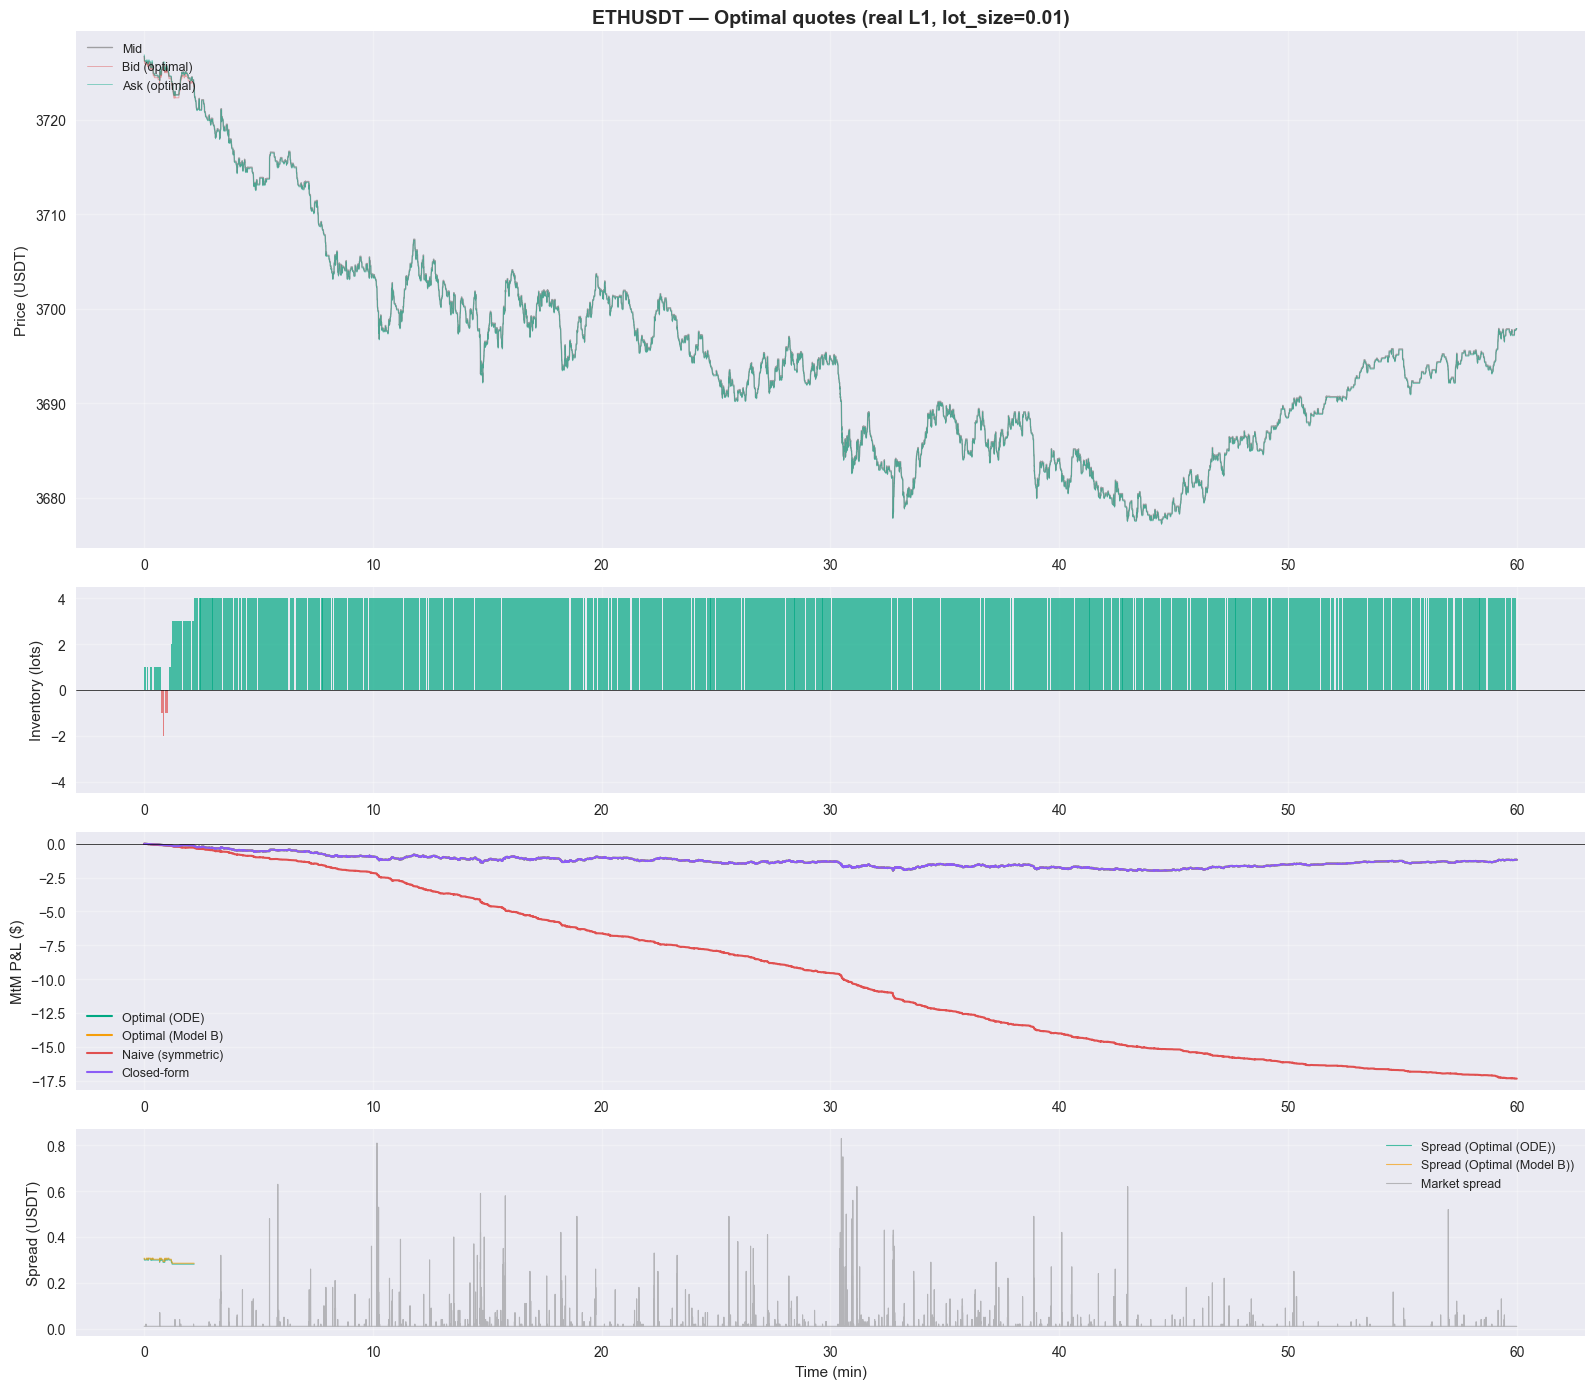

In [10]:
for symbol in SYMBOLS:
    if symbol not in single_window_results:
        continue

    res_opt = single_window_results[symbol]["optimal"]
    N       = len(res_opt.timestamps)
    # Build a minutes axis from the actual timestamps
    ts_sec  = (pd.to_datetime(res_opt.timestamps) -
               pd.to_datetime(res_opt.timestamps[0])).total_seconds().values
    t_min   = ts_sec / 60.0

    fig, axes = plt.subplots(4, 1, figsize=(16, 14),
                             gridspec_kw={"height_ratios": [3, 1.2, 1.5, 1.2]})

    # — Price + optimal quotes —
    ax = axes[0]
    ax.plot(t_min, res_opt.mid_prices, lw=1, color="gray", alpha=0.7, label="Mid")
    ax.plot(t_min, res_opt.mid_prices - res_opt.delta_bid_posted,
            lw=0.6, color="#e05050", alpha=0.5, label="Bid (optimal)")
    ax.plot(t_min, res_opt.mid_prices + res_opt.delta_ask_posted,
            lw=0.6, color="#00a882", alpha=0.5, label="Ask (optimal)")
    ax.set_title(f"{symbol} — Optimal quotes (real L1, lot_size={all_params[symbol]['lot_size']})",
                 fontsize=14, fontweight="bold")
    ax.set_ylabel("Price (USDT)")
    ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.3)

    # — Inventory —
    ax = axes[1]
    inv_plot = res_opt.inventory[1:]
    Q_sym    = all_params[symbol]["Q"]
    bar_w    = t_min[1] - t_min[0] if len(t_min) > 1 else 0.01
    c_inv    = ["#00a882" if v >= 0 else "#e05050" for v in inv_plot]
    ax.bar(t_min, inv_plot.astype(float), width=bar_w, color=c_inv, alpha=0.7)
    ax.set_ylabel("Inventory (lots)")
    ax.set_ylim(-Q_sym - 0.5, Q_sym + 0.5)
    ax.axhline(0, color="k", lw=0.5); ax.grid(True, alpha=0.3)

    # — MtM for all strategies —
    ax = axes[2]
    for strat in STRATEGIES:
        res = single_window_results[symbol][strat]
        ax.plot(t_min, res.mtm[1:], lw=1.5,
                color=COLORS[strat], label=LABELS[strat])
    ax.set_ylabel("MtM P&L ($)")
    ax.axhline(0, color="k", lw=0.5)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # — Posted spread vs market spread —
    ax = axes[3]
    for strat in ["optimal", "optimal_b"]:
        res = single_window_results[symbol][strat]
        ax.plot(t_min, res.delta_bid_posted + res.delta_ask_posted,
                lw=0.8, color=COLORS[strat], alpha=0.7, label=f"Spread ({LABELS[strat]})")
    ax.plot(t_min, 2 * res_opt.market_half_spread,
            lw=0.8, color="gray", alpha=0.5, label="Market spread")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Spread (USDT)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

### Single-window summary table ───────────────────────────

In [11]:
rows = []
for symbol in SYMBOLS:
    if symbol not in single_window_results:
        continue
    for strat in STRATEGIES:
        res = single_window_results[symbol][strat]
        rows.append({
            "Symbol":     symbol,
            "Strategy":   LABELS[strat],
            "P&L ($)":    f"{res.pnl:+.6f}",
            "Bid fills":  res.n_bid_fills,
            "Ask fills":  res.n_ask_fills,
            "Tot. fills": res.total_fills,
            "Final inv":  f"{res.final_inventory:+d}",
            "Bid pass%":  f"{res.bid_passive_rate:.0%}",
            "Ask pass%":  f"{res.ask_passive_rate:.0%}",
            "Fees ($)":   f"{res.fees_paid:.6f}",

        })

summary_df = pd.DataFrame(rows)
# Use print instead of display() so the script runs outside Jupyter
print("\n" + summary_df.to_string(index=False))

print("\nPassivity note: bid/ask pass% < 50% means quotes are often inside the")
print("spread and cannot be executed as passive limit orders on that data.")


 Symbol          Strategy    P&L ($)  Bid fills  Ask fills  Tot. fills Final inv Bid pass% Ask pass% Fees ($)
BTCUSDT     Optimal (ODE)  -0.011921          4          0           4        +4        3%        0% 0.038483
BTCUSDT Optimal (Model B)  -0.012166          4          0           4        +4        3%        0% 0.038483
BTCUSDT Naive (symmetric)  -5.493741        178        181         359        -3       84%       94% 3.447017
BTCUSDT       Closed-form  +0.695008          4          0           4        +4       27%        0% 0.038413
ETHUSDT     Optimal (ODE)  -1.180972         17         13          30        +4        4%        2% 0.111757
ETHUSDT Optimal (Model B)  -1.180430         17         13          30        +4        4%        2% 0.111757
ETHUSDT Naive (symmetric) -17.359793       1266       1270        2536        -4       84%       83% 9.368779
ETHUSDT       Closed-form  -1.180986         17         13          30        +4        4%        2% 0.111757

Passivit

### Poisson comparison (optional) ─────────────────────────


BTCUSDT — Poisson vs empirical (same window):
  Optimal (ODE)         
    Empirical:  PnL=-0.011921 $,  fills=4
    Poisson MC: E[PnL]=-32224.3300 $,  E[fills]=42.7
  Naive (symmetric)     
    Empirical:  PnL=-5.493741 $,  fills=359
    Poisson MC: E[PnL]=-11116.7876 $,  E[fills]=19.9
  Note: Poisson uses Delta=85.07 as trade size,
        empirical uses lot_size=0.001 — compare fills not raw PnL.

ETHUSDT — Poisson vs empirical (same window):
  Optimal (ODE)         
    Empirical:  PnL=-1.180972 $,  fills=30
    Poisson MC: E[PnL]=-12985.4586 $,  E[fills]=1738.4
  Naive (symmetric)     
    Empirical:  PnL=-17.359793 $,  fills=2536
    Poisson MC: E[PnL]=-8227.5804 $,  E[fills]=1316.1
  Note: Poisson uses Delta=29.33 as trade size,
        empirical uses lot_size=0.01 — compare fills not raw PnL.


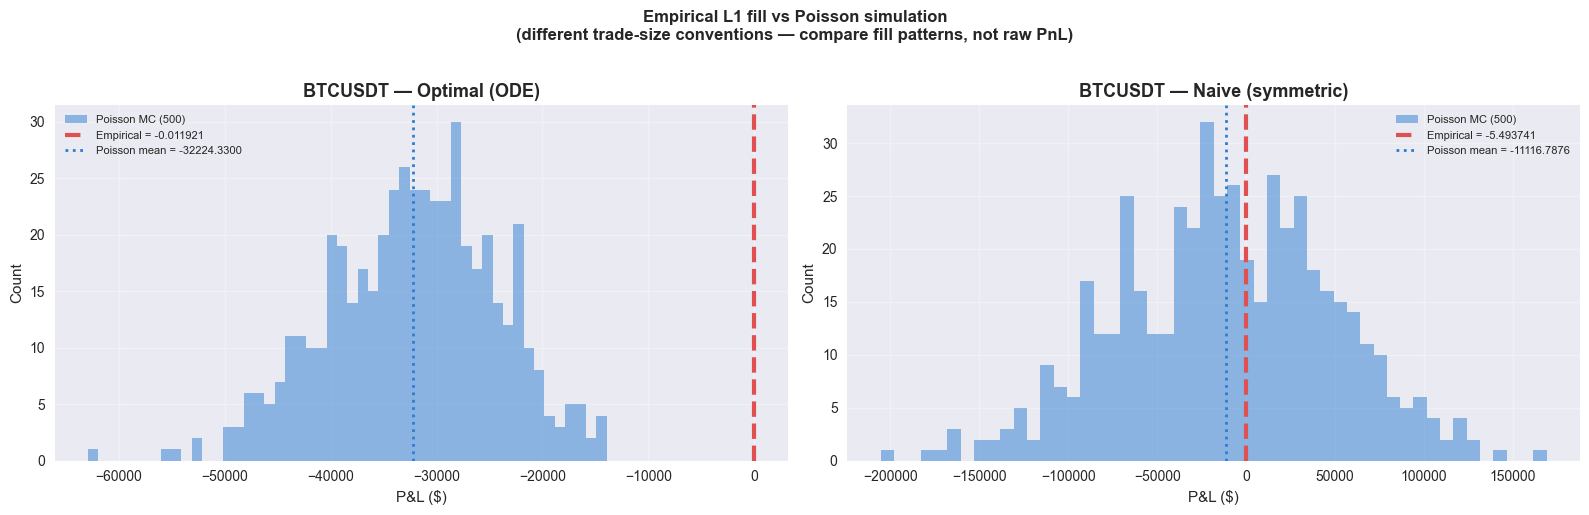

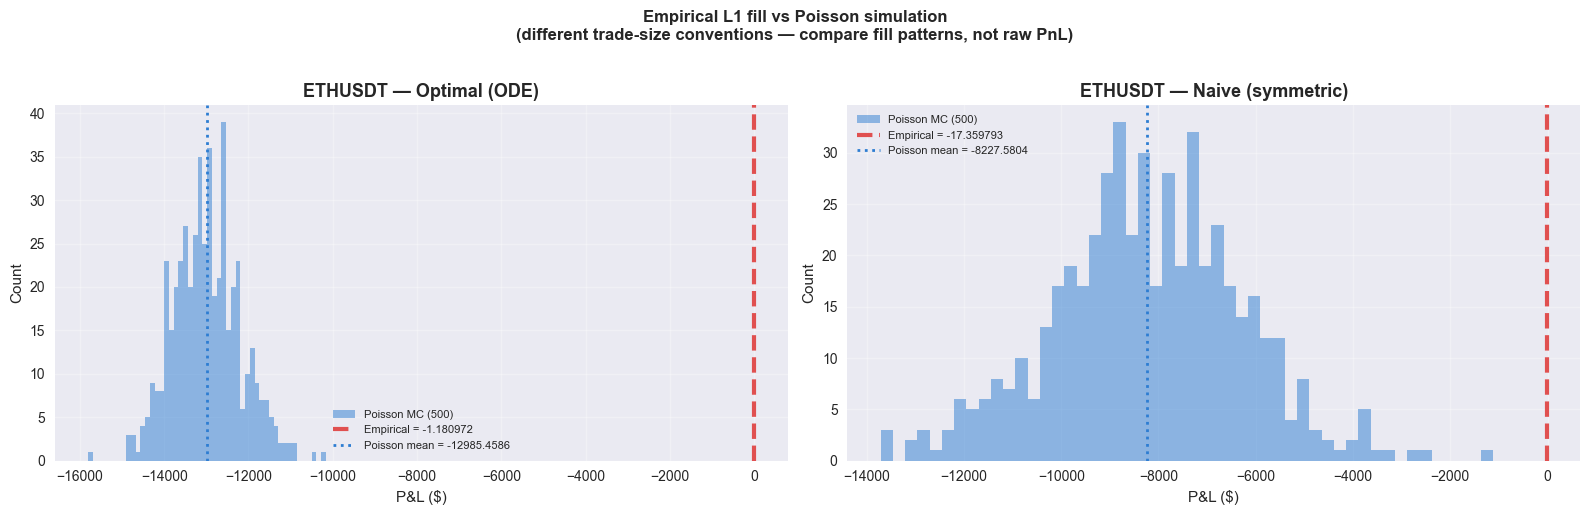

In [12]:
# This cell compares the empirical fill counts against a Poisson simulation
# using the calibrated intensity Λ(δ) = A·exp(−k·δ). It requires the
# market_making.simulation.backtest module; if unavailable it is skipped.
try:
    from market_making.simulation.backtest import BacktestConfig
    from market_making.simulation.backtest import run_backtest as run_backtest_poisson
    _HAS_POISSON = True
except ImportError:
    print("market_making.simulation.backtest not found — Poisson comparison skipped.")
    _HAS_POISSON = False

if _HAS_POISSON:
    comparison_results = {}
    for symbol in SYMBOLS:
        if symbol not in all_intervals:
            continue
        iv     = all_intervals[symbol]
        params = all_params[symbol]

        mid_ts = iv["timestamp"].iloc[len(iv) // 2]
        end_ts = mid_ts + pd.Timedelta(seconds=WINDOW_SECONDS)
        window = iv[(iv["timestamp"] >= mid_ts) & (iv["timestamp"] < end_ts)].copy()
        if len(window) < 100:
            continue

        mid_arr = window["mid"].values
        comparison_results[symbol] = {"empirical": single_window_results[symbol]}

        poisson_results = {}
        for strat in ["optimal", "naive"]:
            cfg = BacktestConfig(
                params=params, gamma=DEFAULT_GAMMA,
                T=float(window["dt"].sum()),
                N_t=len(window), N_sim=500, seed=42,
                strategy=strat, mid_prices=mid_arr,
            )
            poisson_results[strat] = run_backtest_poisson(cfg)
        comparison_results[symbol]["poisson"] = poisson_results

        print(f"\n{symbol} — Poisson vs empirical (same window):")
        for strat in ["optimal", "naive"]:
            emp = single_window_results[symbol][strat]
            poi = poisson_results[strat]
            print(f"  {LABELS[strat]:22s}")
            print(f"    Empirical:  PnL={emp.pnl:+.6f} $,  fills={emp.total_fills}")
            print(f"    Poisson MC: E[PnL]={poi.mean_pnl:+.4f} $,  E[fills]={poi.mean_fills:.1f}")
        print(f"  Note: Poisson uses Delta={params['Delta']:.2f} as trade size,")
        print(f"        empirical uses lot_size={params['lot_size']} — compare fills not raw PnL.")

    # Distribution plot
    if comparison_results:
        for symbol in SYMBOLS:
            if symbol not in comparison_results:
                continue
            cr = comparison_results[symbol]
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            for col, strat in enumerate(["optimal", "naive"]):
                ax      = axes[col]
                poi     = cr["poisson"][strat]
                emp_pnl = cr["empirical"][strat].pnl
                ax.hist(poi.pnl, bins=50, alpha=0.5, color="#2d7dd2", label="Poisson MC (500)")
                ax.axvline(emp_pnl, color="#e05050", lw=3, ls="--",
                           label=f"Empirical = {emp_pnl:+.6f}")
                ax.axvline(poi.mean_pnl, color="#2d7dd2", lw=2, ls=":",
                           label=f"Poisson mean = {poi.mean_pnl:+.4f}")
                ax.set_title(f"{symbol} — {LABELS[strat]}", fontsize=13, fontweight="bold")
                ax.set_xlabel("P&L ($)"); ax.set_ylabel("Count")
                ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
            plt.suptitle("Empirical L1 fill vs Poisson simulation\n"
                         "(different trade-size conventions — compare fill patterns, not raw PnL)",
                         fontsize=12, fontweight="bold", y=1.02)
            plt.tight_layout(); plt.show()

### Rolling backtest ────────────────────────────────────

In [13]:
WINDOW_MINUTES = 30
STRIDE_MINUTES = 15
MAX_WINDOWS    = 200

rolling_all = {}

for symbol in SYMBOLS:
    if symbol not in all_intervals:
        continue
    iv     = all_intervals[symbol]
    params = all_params[symbol]

    print(f"\n{'='*55}\nRolling backtest: {symbol}\n{'='*55}")

    starts = pd.date_range(
        iv["timestamp"].min() + pd.Timedelta(minutes=5),
        iv["timestamp"].max() - pd.Timedelta(minutes=WINDOW_MINUTES + 5),
        freq=f"{STRIDE_MINUTES}min",
    )
    if len(starts) > MAX_WINDOWS:
        step   = len(starts) // MAX_WINDOWS
        starts = starts[::step][:MAX_WINDOWS]

    print(f"  {len(starts)} windows × {WINDOW_MINUTES}min, stride {STRIDE_MINUTES}min")

    results_list = []
    for i, start in enumerate(starts):
        end = start + pd.Timedelta(minutes=WINDOW_MINUTES)
        w   = iv[(iv["timestamp"] >= start) & (iv["timestamp"] < end)].copy()
        if len(w) < 50:
            continue

        mid_w  = w["mid"].values
        ret_w  = np.diff(mid_w)
        row = {
            "start":           start,
            "n_intervals":     len(w),
            "mid_price":       float(np.mean(mid_w)),
            "sigma_realised":  float(np.std(ret_w)) if len(ret_w) > 1 else 0.0,
            "mean_half_spread": float(w["half_spread"].mean()),
        }

        for strat in STRATEGIES:
            try:
                res = run_backtest_real_lob(
                    w, params, DEFAULT_GAMMA,
                    strategy=strat, maker_fee=0.0001, symbol=symbol,
                )
                row[f"{strat}_pnl"]          = res.pnl
                row[f"{strat}_fills"]        = res.total_fills
                row[f"{strat}_bid_fills"]    = res.n_bid_fills
                row[f"{strat}_ask_fills"]    = res.n_ask_fills
                row[f"{strat}_inv_T"]        = res.final_inventory
                row[f"{strat}_abs_inv_mean"] = float(np.mean(np.abs(res.inventory)))
                row[f"{strat}_fees"]         = res.fees_paid
                row[f"{strat}_spread_mean"]  = res.mean_spread

            except Exception as exc:
                row[f"{strat}_pnl"] = np.nan
                print(f"  [{symbol}] window {start}: {strat} failed — {exc}")

        results_list.append(row)
        if (i + 1) % 50 == 0 or i == len(starts) - 1:
            print(f"  [{i+1}/{len(starts)}] done")

    roll_df = pd.DataFrame(results_list)
    rolling_all[symbol] = roll_df
    print(f"  Completed: {len(roll_df)} windows")


Rolling backtest: BTCUSDT
  200 windows × 30min, stride 15min
  Completed: 7 windows

Rolling backtest: ETHUSDT
  200 windows × 30min, stride 15min
  Completed: 7 windows


### Rolling diagnostics plot ─────────────────────────────

/var/folders/vm/yts9xph547jfyqtmcm7tcg5m0000gn/T/ipykernel_92290/3907184521.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=[LABELS[s] for s in STRATEGIES],


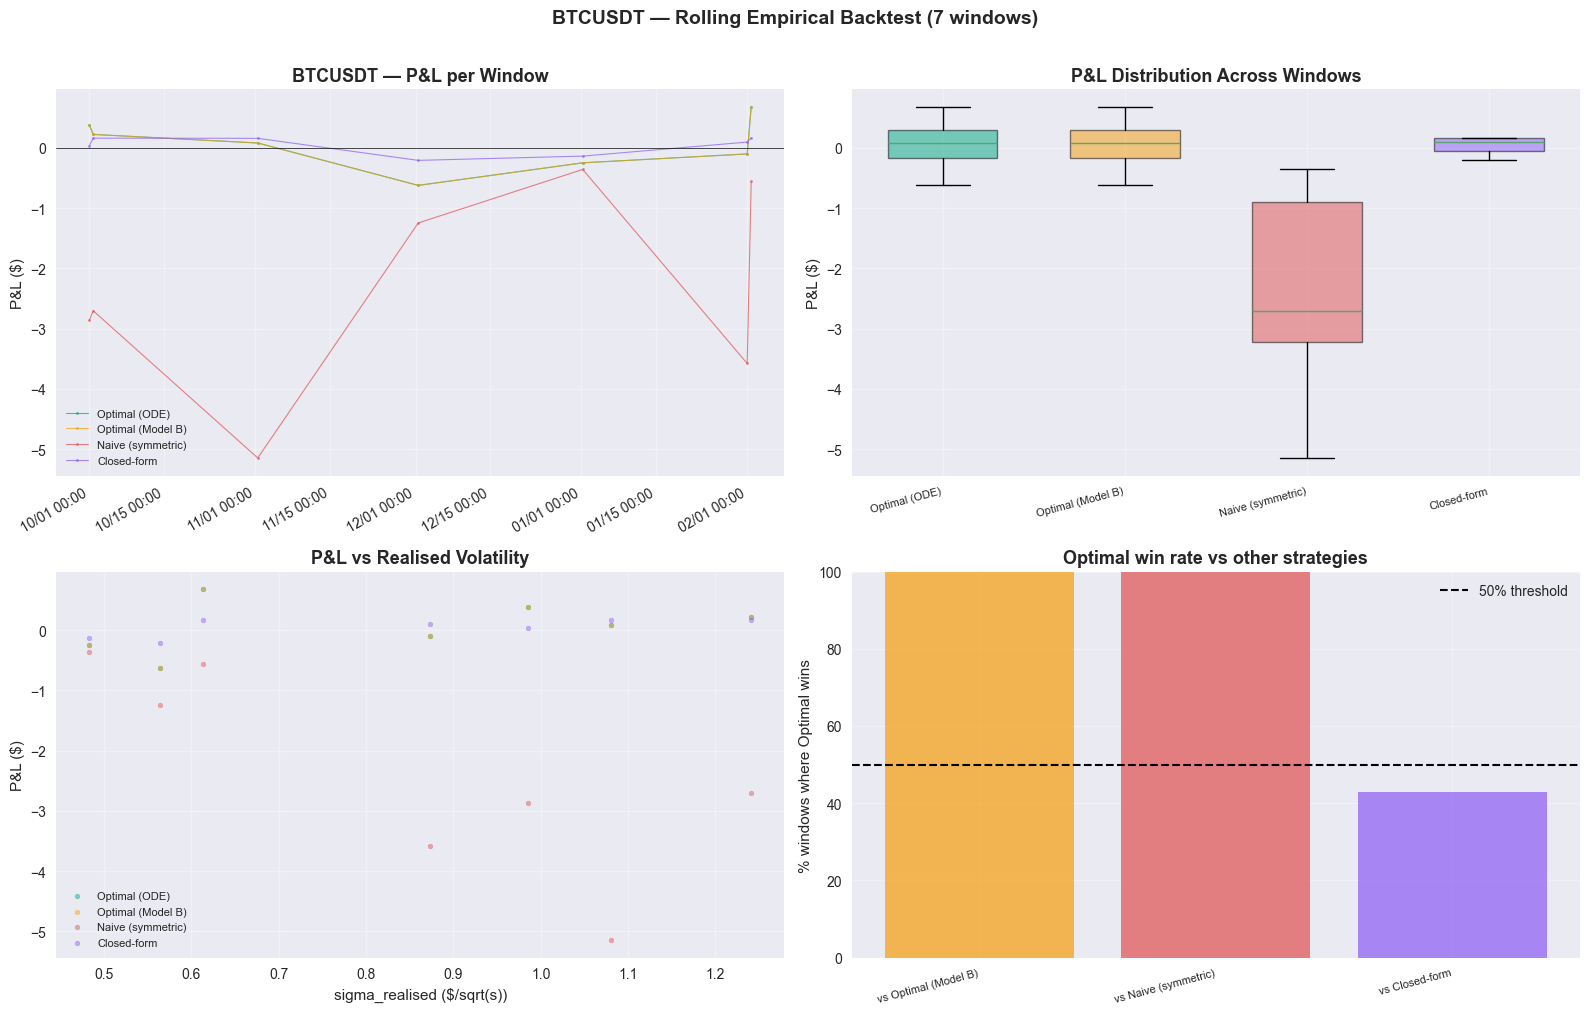

/var/folders/vm/yts9xph547jfyqtmcm7tcg5m0000gn/T/ipykernel_92290/3907184521.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=[LABELS[s] for s in STRATEGIES],


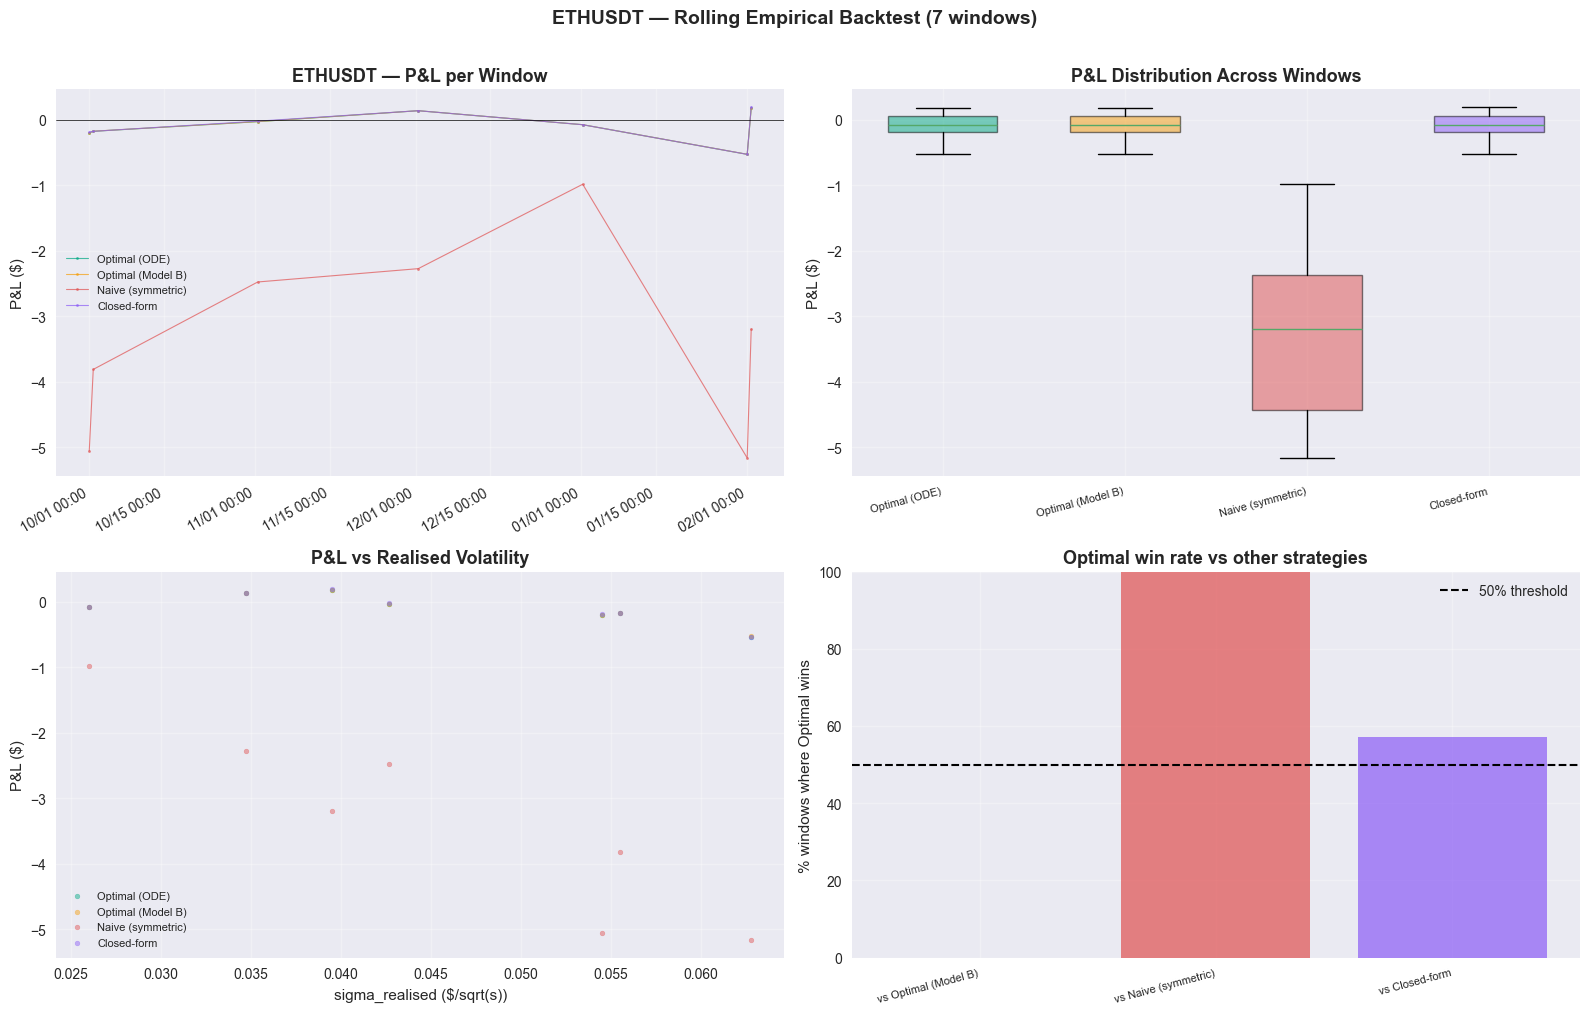

In [14]:
for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    roll_df = rolling_all[symbol]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # — P&L over time —
    ax = axes[0, 0]
    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        if col in roll_df:
            ax.plot(roll_df["start"], roll_df[col], "o-", ms=2, lw=0.8,
                    color=COLORS[strat], label=LABELS[strat], alpha=0.7)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{symbol} — P&L per Window", fontsize=13, fontweight="bold")
    ax.set_ylabel("P&L ($)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # — P&L boxplot —
    ax = axes[0, 1]
    data_box = [roll_df[f"{s}_pnl"].dropna().values for s in STRATEGIES]
    bp = ax.boxplot(data_box, labels=[LABELS[s] for s in STRATEGIES],
                    patch_artist=True, widths=0.6)
    for patch, strat in zip(bp["boxes"], STRATEGIES):
        patch.set_facecolor(COLORS[strat]); patch.set_alpha(0.5)
    ax.set_title("P&L Distribution Across Windows", fontsize=13, fontweight="bold")
    ax.set_ylabel("P&L ($)"); ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)

    # — P&L vs realised sigma —
    ax = axes[1, 0]
    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        if col in roll_df:
            ax.scatter(roll_df["sigma_realised"], roll_df[col],
                       s=12, alpha=0.45, color=COLORS[strat], label=LABELS[strat])
    ax.set_title("P&L vs Realised Volatility", fontsize=13, fontweight="bold")
    ax.set_xlabel("sigma_realised ($/sqrt(s))"); ax.set_ylabel("P&L ($)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # — Pairwise win rates: optimal vs every other strategy —
    ax = axes[1, 1]
    others   = [s for s in STRATEGIES if s != "optimal"]
    win_vals = []
    win_lbls = []
    for other in others:
        valid = roll_df[["optimal_pnl", f"{other}_pnl"]].dropna()
        opt_wins  = (valid["optimal_pnl"] > valid[f"{other}_pnl"]).sum()
        win_vals.append(opt_wins / max(len(valid), 1) * 100)
        win_lbls.append(f"vs {LABELS[other]}")
    bars = ax.bar(win_lbls, win_vals,
                  color=[COLORS[s] for s in others], alpha=0.7)
    ax.axhline(50, color="k", ls="--", lw=1.5, label="50% threshold")
    ax.set_title("Optimal win rate vs other strategies",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("% windows where Optimal wins")
    ax.set_ylim(0, 100); ax.legend(); ax.grid(True, alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)

    plt.suptitle(f"{symbol} — Rolling Empirical Backtest ({len(roll_df)} windows)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()

### Cumulative P&L ───────────────────────────────────────

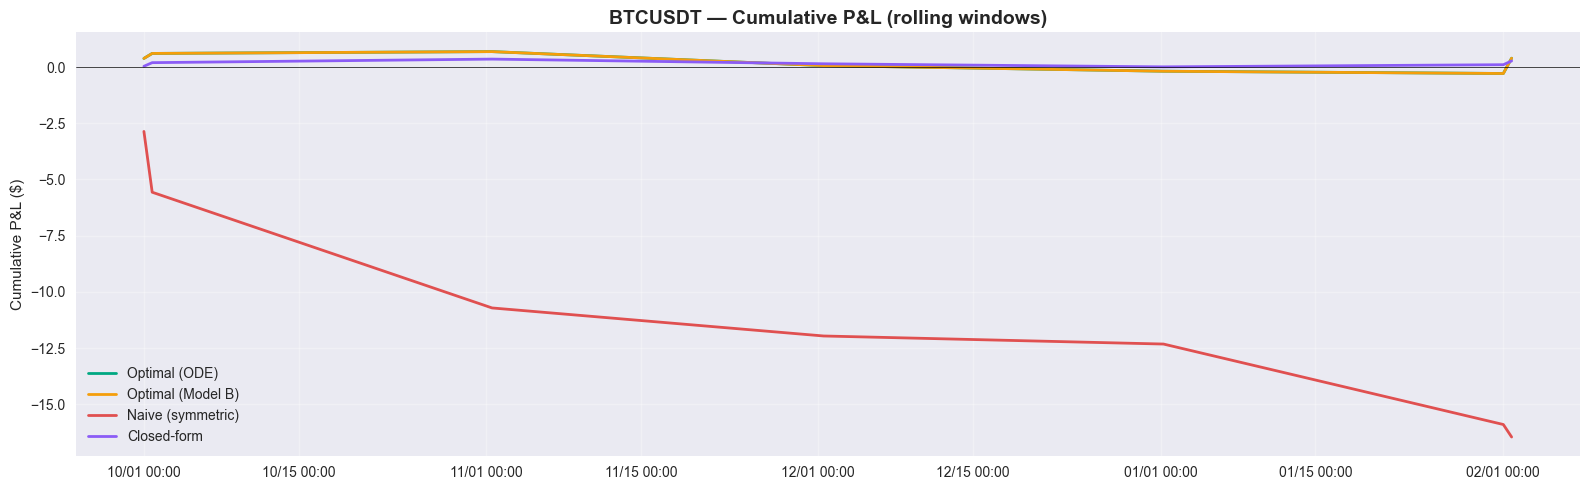

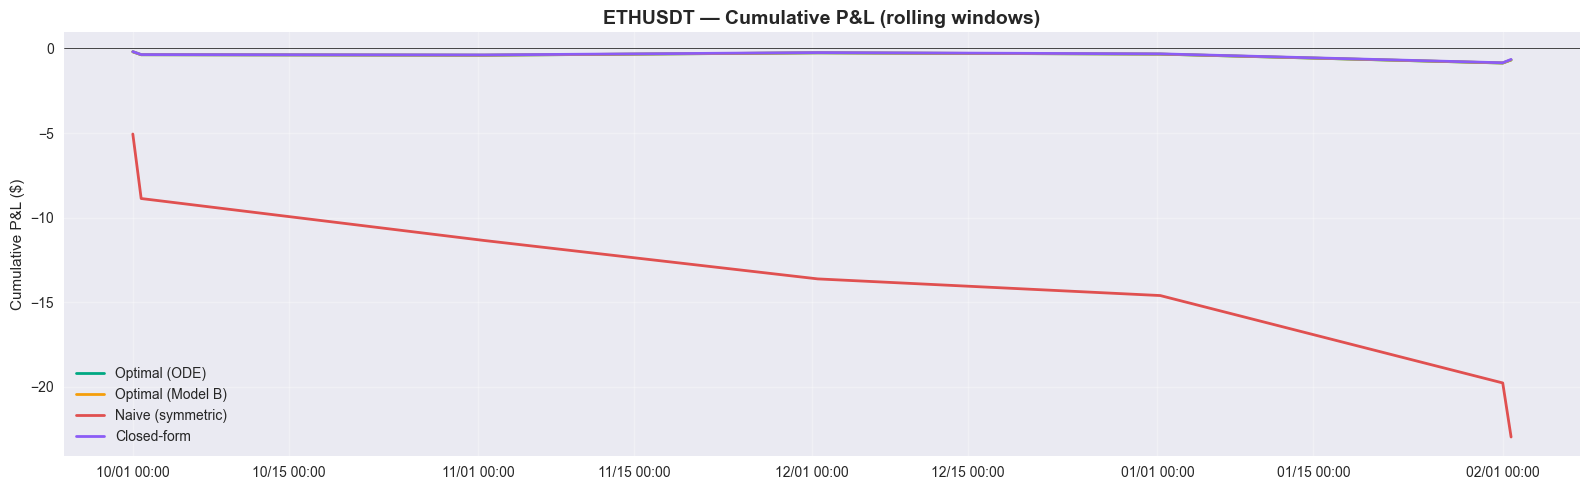

In [15]:
for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    roll_df = rolling_all[symbol]

    fig, ax = plt.subplots(figsize=(16, 5))
    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        if col in roll_df:
            cum = roll_df[col].fillna(0).cumsum()
            ax.plot(roll_df["start"], cum, lw=2,
                    color=COLORS[strat], label=LABELS[strat])
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{symbol} — Cumulative P&L (rolling windows)",
                 fontsize=14, fontweight="bold")
    ax.set_ylabel("Cumulative P&L ($)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

### Rolling summary table ───────────────────────────────

In [16]:
for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    roll_df = rolling_all[symbol]

    print(f"\n{'='*75}")
    print(f"  {symbol} — Rolling Backtest Summary ({len(roll_df)} windows)")
    print(f"{'='*75}")
    print(f"  {'Strategy':<22s} {'Mean PnL':>10s} {'Std PnL':>10s} "
          f"{'Sharpe':>8s} {'Win vs opt%':>12s} {'Med Fills':>10s} {'Avg |inv|':>10s}")
    print(f"  {'_'*85}")

    # Build valid pairwise comparison with optimal
    opt_col = "optimal_pnl"

    for strat in STRATEGIES:
        col  = f"{strat}_pnl"
        fcol = f"{strat}_fills"
        icol = f"{strat}_abs_inv_mean"
        if col not in roll_df:
            continue

        pnls    = roll_df[col].dropna()
        fills   = roll_df[fcol].dropna() if fcol in roll_df else pd.Series([0])
        abs_inv = roll_df[icol].dropna() if icol in roll_df else pd.Series([0])

        mean_p = pnls.mean()
        std_p  = pnls.std()
        sharpe = mean_p / std_p if std_p > 0 else 0.0

        if strat == "optimal":
            win_pct_str = "—"
        else:
            valid = roll_df[[opt_col, col]].dropna()
            if len(valid) > 0:
                # "Win vs opt" means optimal BEATS this strategy
                win_pct = (valid[opt_col] > valid[col]).mean() * 100
                win_pct_str = f"{win_pct:.1f}%"
            else:
                win_pct_str = "?"

        print(f"  {LABELS[strat]:<22s} {mean_p:>+10.6f} {std_p:>10.6f} "
              f"{sharpe:>8.3f} {win_pct_str:>12s} "
              f"{fills.median():>10.0f} {abs_inv.mean():>10.2f}")


  BTCUSDT — Rolling Backtest Summary (7 windows)
  Strategy                 Mean PnL    Std PnL   Sharpe  Win vs opt%  Med Fills  Avg |inv|
  _____________________________________________________________________________________
  Optimal (ODE)           +0.056179   0.428533    0.131            —          4       3.60
  Optimal (Model B)       +0.055935   0.428533    0.131       100.0%          4       3.60
  Naive (symmetric)       -2.350325   1.737532   -1.353       100.0%        124       2.30
  Closed-form             +0.038535   0.152951    0.252        42.9%          3       2.06

  ETHUSDT — Rolling Backtest Summary (7 windows)
  Strategy                 Mean PnL    Std PnL   Sharpe  Win vs opt%  Med Fills  Avg |inv|
  _____________________________________________________________________________________
  Optimal (ODE)           -0.097933   0.238038   -0.411            —          8       3.75
  Optimal (Model B)       -0.097508   0.237863   -0.410         0.0%          8       3

### Export ───────────────────────────────────────────────

In [17]:
EXPORT_DIR = DATA_DIR.parent / "backtest_results"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    out_path = EXPORT_DIR / f"rolling_backtest_{symbol}.csv"
    rolling_all[symbol].to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

print("\nExport complete.")

Saved: /Users/chedimnif/Desktop/Imperial/Market-Microstructure-/project/data/data/backtest_results/rolling_backtest_BTCUSDT.csv
Saved: /Users/chedimnif/Desktop/Imperial/Market-Microstructure-/project/data/data/backtest_results/rolling_backtest_ETHUSDT.csv

Export complete.


### Final summary ───────────────────────────────────────

In [18]:
print("=" * 70)
print("  EMPIRICAL BACKTEST SUMMARY")
print("=" * 70)

for symbol in SYMBOLS:
    if symbol not in rolling_all:
        continue
    params  = all_params[symbol]
    roll_df = rolling_all[symbol]

    valid    = roll_df[["optimal_pnl", "naive_pnl"]].dropna()
    opt_wins = (valid["optimal_pnl"] > valid["naive_pnl"]).sum()

    print(f"\n  {symbol}")
    print(f"    sigma={params['sigma']:.4f},  A={params['A']:.4f},  k={params['k']:.4f}")
    print(f"    Delta={params['Delta']:.2f}$ (notional),  lot_size={params['lot_size']}")
    print(f"    gamma = {DEFAULT_GAMMA}")
    print(f"    Windows: {len(roll_df)}")
    print(f"    Optimal beats Naive: {opt_wins}/{len(valid)} "
          f"({opt_wins/max(len(valid), 1):.0%})")
    for strat in STRATEGIES:
        col = f"{strat}_pnl"
        if col in roll_df:
            pnls   = roll_df[col].dropna()
            std    = pnls.std()
            sharpe = pnls.mean() / std if std > 0 else 0
            print(f"    {LABELS[strat]:<22s}: "
                  f"mean={pnls.mean():+.6f},  "
                  f"std={std:.6f},  Sharpe={sharpe:.3f}")

print("\n" + "=" * 70)

  EMPIRICAL BACKTEST SUMMARY

  BTCUSDT
    sigma=5.0159,  A=0.5028,  k=1.0099
    Delta=85.07$ (notional),  lot_size=0.001
    gamma = 0.01
    Windows: 7
    Optimal beats Naive: 7/7 (100%)
    Optimal (ODE)         : mean=+0.056179,  std=0.428533,  Sharpe=0.131
    Optimal (Model B)     : mean=+0.055935,  std=0.428533,  Sharpe=0.131
    Naive (symmetric)     : mean=-2.350325,  std=1.737532,  Sharpe=-1.353
    Closed-form           : mean=+0.038535,  std=0.152951,  Sharpe=0.252

  ETHUSDT
    sigma=0.2699,  A=0.7622,  k=8.6003
    Delta=29.33$ (notional),  lot_size=0.01
    gamma = 0.01
    Windows: 7
    Optimal beats Naive: 7/7 (100%)
    Optimal (ODE)         : mean=-0.097933,  std=0.238038,  Sharpe=-0.411
    Optimal (Model B)     : mean=-0.097508,  std=0.237863,  Sharpe=-0.410
    Naive (symmetric)     : mean=-3.280219,  std=1.523976,  Sharpe=-2.152
    Closed-form           : mean=-0.093183,  std=0.241034,  Sharpe=-0.387

